# Naive

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset

In [4]:
df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 3. Basic Exploration

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (48842, 15)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


In [7]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

## 4. Check Target Variable

In [9]:
df['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [10]:
df['income'].value_counts(normalize=True)

income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

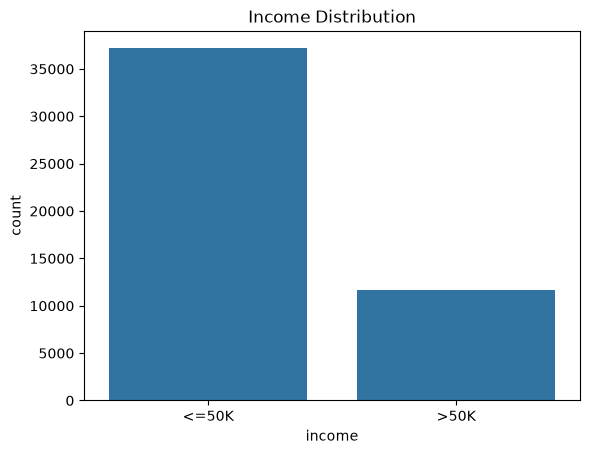

In [11]:
sns.countplot(x='income',data=df)
plt.title("Income Distribution")
plt.show()

## 5. Check Missing Values

In [12]:
df.replace ('?',np.nan, inplace=True)
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

## 6. Handle Missing Values

In [20]:
for col in df.columns:
    if df[col].dtype == 'str':
        df[col]=df[col].fillna(df[col].mode()[0], inplace=True)

In [21]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [19]:
import pandas as pd

print(pd.__version__)

3.0.3


### 7. Exploratory Data Analysis (EDA)

### Age Distribution

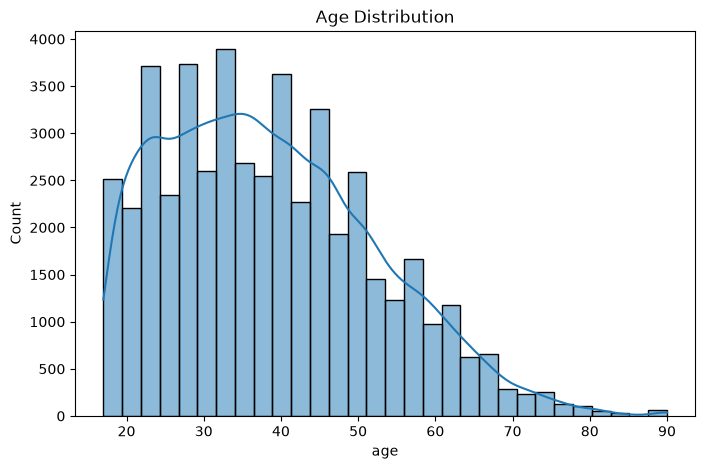

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### Education Distribution

### Income by Gender

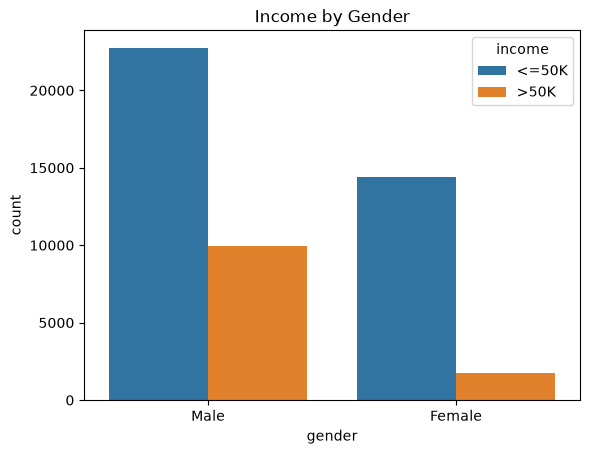

In [24]:
sns.countplot(x='gender', hue='income' ,data=df)
plt.title("Income by Gender")
plt.show()

## Correlation Heatmap

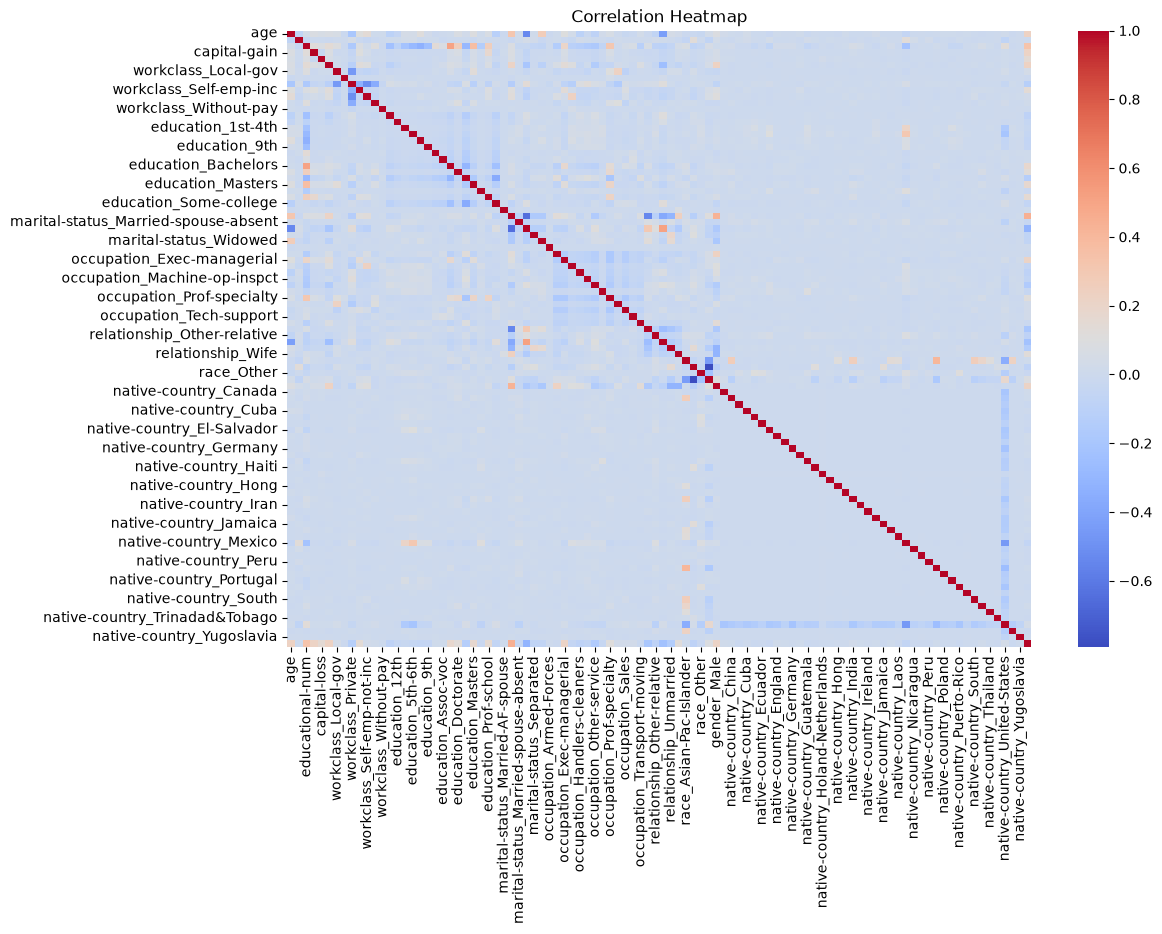

In [28]:
temp_df = pd.get_dummies(df, drop_first =True)
plt.figure(figsize=(12,8))
sns.heatmap(temp_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 8. Convert Categorical Variables

In [29]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,25,226802,7,0,0,40,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
1,38,89814,9,0,0,50,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,28,336951,12,0,0,40,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,44,160323,10,7688,0,40,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,18,103497,10,0,0,30,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


### 9. Separate Features and Target

In [30]:
X = df_encoded.drop('income_>50K', axis=1)

y = df_encoded['income_>50K']

### 10. Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (39073, 97)
Testing Shape: (9769, 97)


### 11. Train Naive Bayes Model

In [32]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[29676., 9397.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.76,0.24]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[bool](2,)","[False, True]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,11.11
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](97,)","['age','fnlwgt','educational-num',...,'native-country_United-States', 'native-country_Vietnam','native-country_Yugoslavia']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,97
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 97)","[[ 36.82,189943.04, 9.59,..., 0.91, 0. , 0. ], [ 44.3 ,188675.92, 11.6 ,..., 0.93, 0. , 0. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 97)","[[2.10e+02,1.13e+10,1.71e+01,...,1.12e+01,1.11e+01,1.11e+01], [1.23e+02,1.05e+10,1.67e+01,...,1.12e+01,1.11e+01,1.11e+01]]"


### 12. Make Predictions

In [33]:
y_pred = nb_model.predict(X_test)

print(y_pred[:20])

[False False  True False False False False  True False False False False
 False False False False False False False False]


### 13. Accuracy Score

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 79.92 %


### 14. Confusion Matrix

In [35]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7097  382]
 [1580  710]]


In [ ]:
plt.figure(figsize=(6,4))